# Verovio conversion to MEI

This notebook is a separate conversion front door for the parsing workflow in `testing_annot_stats.ipynb`. The goal is to turn MusicXML (`.xml`, `.musicxml`, `.mxl`), Humdrum/Kern, already-MEI XML, and optionally MIDI sources into MEI first, then use those converted MEI files as the stable analysis inputs.

Why this shape: MEI gives the downstream parser explicit `xml:id` anchors, which are useful for annotation, Verovio highlighting, and round-tripping selected notes back into the rendered score.

## Capability assessment

Verovio is a good conversion layer for the formats we care about most here:

- MEI input: pass through unchanged. It is already the target analysis format, so no Verovio conversion is needed.
- MusicXML input: plain `.xml` / `.musicxml` files use Verovio's MusicXML importer. Compressed `.mxl` files use Verovio's ZIP loader before MEI export.
- Humdrum/Kern input: `.krn`, `.kern`, and `.hum` text files use Verovio's Humdrum importer. Conversion quality depends on how explicit the Kern encoding is.
- MIDI input: `.mid` / `.midi` files are not loaded by Verovio directly. The helper converts MIDI to MusicXML with music21, then sends that MusicXML to Verovio.

Practical limits: treat every conversion as an import/normalization step, not as a lossless archival transform. This is especially true for MIDI, where spelling, voices, notation, articulations, and meter/key structure may need review after music21 quantization. Generated IDs are stable enough for a fixed Verovio version plus fixed options, but they are not a permanent scholarly identifier across Verovio upgrades. Keep the original source and a conversion report next to every generated MEI file.

In [1]:
# Parameters
from pathlib import Path

OUTPUT_DIR = Path("converted_mei/verovio_conversion_tests")
TIMEOUT_SECONDS = 90
RENDER_FIRST_PAGE = True
N_JOBS = -1                 # 1 = serial; >1 uses workers; -1 = os.cpu_count()
SHOW_PROGRESS = True        # tqdm progress bar

# Output naming controls for converted files.
# Example: OUTPUT_SUFFIX = "bach_test" -> *_verovio_bach_test.mei
OUTPUT_SUFFIX = ""
ADD_TIMESTAMP = False       # append YYYYMMDD_HHMMSS to converted filenames

# Test sources proposed for the conversion workflow.
# Supported inputs: .mei, .xml/.musicxml/.mxl, .krn/.kern/.hum, and .mid/.midi.
# MIDI is converted through music21 -> MusicXML before Verovio, so inspect results carefully.
FILE_SOURCES = [
    "https://analyse.hfm-weimar.de/database/02/PrJode_Jos0302_COM_1-5_MissaDapac_002_00006.xml",
    "https://raw.githubusercontent.com/humdrum-tools/bach-wtc-fugues/refs/heads/master/kern/wtc1f04.krn",
    "https://raw.githubusercontent.com/humdrum-tools/bach-wtc/refs/heads/main/kern/wtc1f22.krn",
    "https://raw.githubusercontent.com/piasteuck/winterreise-analysis/refs/heads/main/Schubert_Winterreise_Dataset_v2-0/01_RawData/score_musicxml/Schubert_D911-20.xml",
    # Add local or remote .mxl/.mid files here when probing those import paths.
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('converted_mei/verovio_conversion_tests')

## Convert and inspect

The conversion helper runs each Verovio import in a child Python process. That is deliberate: Verovio is native code, and a subprocess keeps the notebook alive if one malformed source crashes the converter. For MIDI inputs, music21 creates an intermediate MusicXML file first; the report records that path so the notation cleanup step is auditable.

In [2]:
import json

import pandas as pd
from IPython.display import display

from scripts.test_verovio_conversion import convert_sources, _print_summary

records = convert_sources(
    FILE_SOURCES,
    output_dir=OUTPUT_DIR,
    timeout=TIMEOUT_SECONDS,
    render_first_page=RENDER_FIRST_PAGE,
    n_jobs=N_JOBS,
    output_suffix=OUTPUT_SUFFIX,
    timestamp=ADD_TIMESTAMP,
    show_progress=SHOW_PROGRESS,
)

report_path = OUTPUT_DIR / "conversion_report.json"
report_path.write_text(json.dumps(records, indent=2), encoding="utf-8")

conversion_df = pd.DataFrame(records)
_print_summary(records)

display_cols = [
    "status",
    "input_from",
    "converted",
    "overwritten",
    "page_count",
    "measure_count",
    "note_count",
    "rest_count",
    "xml_id_count",
    "duplicate_xml_id_count",
    "svg_ok",
    "verovio_version",
    "output_mei",
    "message",
    "error",
]
display(conversion_df[[c for c in display_cols if c in conversion_df.columns]])
print(f"Report written to: {report_path}")

Converting with Verovio:   0%|          | 0/4 [00:00<?, ?file/s]


=== Verovio Conversion Capability Probe ===

status  input     pages measures   notes  xml:id  dupe  source
--------------------------------------------------------------
ok      musicxml      9       64     797    1588     0  https://analyse.hfm-weimar.de/database/02/PrJode_Jos0302_COM_1-5_MissaD...
ok      humdrum       8      115    1429    3262     0  https://raw.githubusercontent.com/humdrum-tools/bach-wtc-fugues/refs/he...
ok      humdrum       5       75     813    1897     0  https://raw.githubusercontent.com/humdrum-tools/bach-wtc/refs/heads/mai...
ok      musicxml      4       84    1153    3106     0  https://raw.githubusercontent.com/piasteuck/winterreise-analysis/refs/h...

Output paths:
  OVERWROTE: /home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/PrJode_Jos0302_COM_1-5_MissaDapac_002_00006_musicxml_verovio.mei
    source: https://analyse.hfm-weimar.de/database/02/PrJode_Jos0302_COM_1-5_MissaDapac_002_00006.xml
  OVERWROTE: /home/egg

,status,input_from,converted,overwritten,page_count,measure_count,note_count,rest_count,xml_id_count,duplicate_xml_id_count,svg_ok,verovio_version,output_mei,message,error
0,ok,musicxml,True,True,9,64,797,71,1588,0,True,6.0.1-ffbc336,/home/eggi/Nextcloud/code/public_repos/camat_v...,Converted with Verovio.,None
1,ok,humdrum,True,True,8,115,1429,190,3262,0,True,6.0.1-ffbc336,/home/eggi/Nextcloud/code/public_repos/camat_v...,Converted with Verovio.,None
2,ok,humdrum,True,True,5,75,813,115,1897,0,True,6.0.1-ffbc336,/home/eggi/Nextcloud/code/public_repos/camat_v...,Converted with Verovio.,None
3,ok,musicxml,True,True,4,84,1153,76,3106,0,True,6.0.1-ffbc336,/home/eggi/Nextcloud/code/public_repos/camat_v...,Converted with Verovio.,None


Report written to: converted_mei/verovio_conversion_tests/conversion_report.json


/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/PrJode_Jos0302_COM_1-5_MissaDapac_002_00006_musicxml_verovio.mei


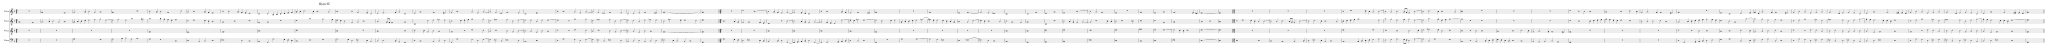

In [3]:
# Render the first successfully converted MEI file.
from camat import vrv_display_svg, vrv_load_from_file, vrv_quiet, vrv_render_page, vrv_set_options

ok_records = [r for r in records if r.get("status") == "ok" and r.get("output_mei")]

if ok_records:
    preview_path = ok_records[0]["output_mei"]
    print(preview_path)
    with vrv_quiet():
        vrv_set_options(pageWidth=12000, pageHeight=1200, scale=40, breaks="none", removeIds=False, xmlIdSeed=0)
        vrv_load_from_file(preview_path, input_from="mei")
        vrv_display_svg(vrv_render_page(1))
else:
    print("No successful conversion to preview.")

In [7]:
converted_sources = [r["output_mei"] for r in ok_records]

print(converted_sources)

['/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/PrJode_Jos0302_COM_1-5_MissaDapac_002_00006_musicxml_verovio.mei', '/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/wtc1f04_humdrum_verovio.mei', '/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/wtc1f22_humdrum_verovio.mei', '/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/Schubert_D911-20_musicxml_verovio.mei']


## Artifact design

Recommended layout:

- `converted_mei/`: generated artifacts, ignored by git.
- `converted_mei/<corpus_or_test_name>/`: one conversion batch.
- `converted_mei/<batch>/_sources/`: cached originals used for the conversion.
- `converted_mei/<batch>/conversion_report.json`: source URL, inferred Verovio input type, MEI path, page count, note count, measure count, xml:id count, duplicate xml:id count, and any error.
- `converted_mei/<batch>/*.mei`: files to feed into `parse_files(...)` after a quick inspection.

Do not overwrite the source files and do not commit converted MEI by default. If a converted MEI becomes a curated fixture, move it to a deliberate fixture/test corpus path and commit it with its source URL and Verovio version in metadata or docs.

In [4]:
# Optional: parse the converted MEI files with the same common-notation parser posture.
from camat.parser_registry import parse_files

PARSE_CONVERTED_MEI = False

converted_sources = [r["output_mei"] for r in ok_records]

if PARSE_CONVERTED_MEI and converted_sources:
    results, dfs_by_name, df_processed = parse_files(
        converted_sources,
        parsing_backend="partitura",
        quiet_native_warnings=True,
        print_parsed_summary=True,
        filter_zero_duration=True,
        adjust_fractional_duration=True,
        parse_enharmonic=True,
        backend="none",
        display_preview_df_pitch=True,
        display_preview_df_events=True,
        include_xml_ids=True,
        try_verovio_mei_conversion=False,
        allow_music21_fallback=False,
        cleanup_remote=False,
        use_remote_cache=False,
        n_jobs=1,
        normalize_mensural_durations=False,
        inject_missing_meter_signature=False,
        prefer_verovio_for_mensural=False,
        use_verovio_mensural_timing=False,
    )
else:
    print("Set PARSE_CONVERTED_MEI = True to parse these converted MEI files:")
    for path in converted_sources:
        print(path)

Set PARSE_CONVERTED_MEI = True to parse these converted MEI files:
/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/PrJode_Jos0302_COM_1-5_MissaDapac_002_00006_musicxml_verovio.mei
/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/wtc1f04_humdrum_verovio.mei
/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/wtc1f22_humdrum_verovio.mei
/home/eggi/Nextcloud/code/public_repos/camat_v2/converted_mei/verovio_conversion_tests/Schubert_D911-20_musicxml_verovio.mei


## Terminal test

The notebook reuses `scripts/test_verovio_conversion.py`. To run the same conversion probe outside Jupyter:

```bash
conda run -n py310 python scripts/test_verovio_conversion.py --n-jobs -1
```

With custom output names:

```bash
conda run -n py310 python scripts/test_verovio_conversion.py --output-suffix trial --timestamp
```

If your shell exposes a direct launcher, this is equivalent:

```bash
py310 scripts/test_verovio_conversion.py --n-jobs -1
```